FIRST 5 ROWS:

   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
1      119.992       157.302        74.997         0.00784           0.00007   
2      122.400       148.650       113.819         0.00968           0.00008   
3      116.682       131.111       111.555         0.01050           0.00009   
4      116.676       137.871       111.366         0.00997           0.00009   
5      116.014       141.781       110.655         0.01284           0.00011   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
1   0.00370   0.00554     0.01109       0.04374             0.426  ...   
2   0.00465   0.00696     0.01394       0.06134             0.626  ...   
3   0.00544   0.00781     0.01633       0.05233             0.482  ...   
4   0.00502   0.00698     0.01505       0.05492             0.517  ...   
5   0.00655   0.00908     0.01966       0.06425             0.584  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA

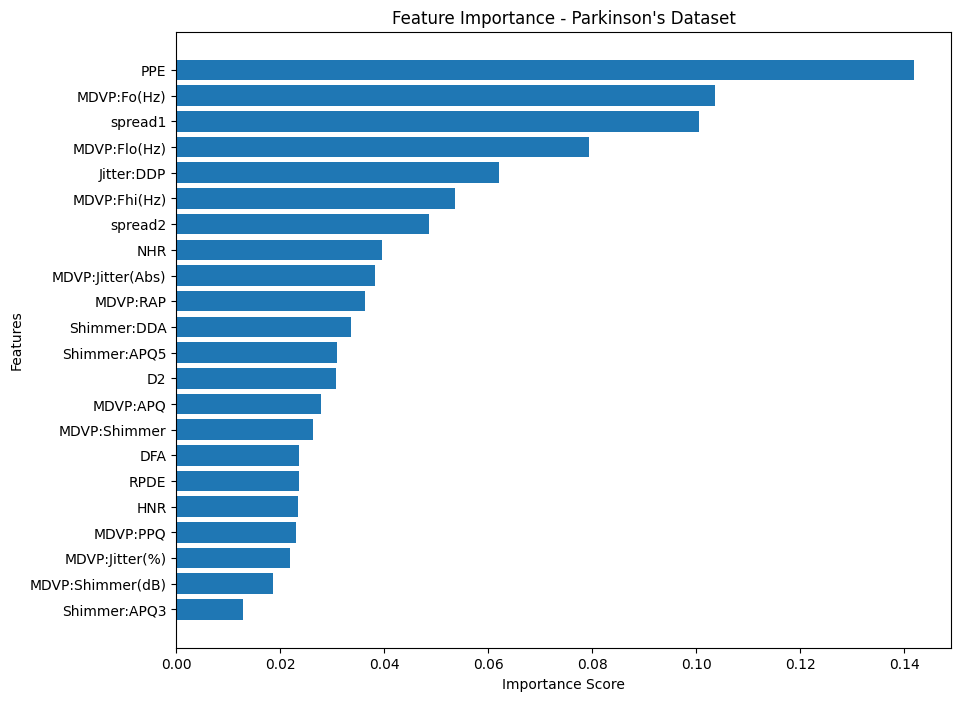

In [ ]:
# ================================
# PARKINSON'S DISEASE PREDICTION
# VERSION 1
# ================================

# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# COLUMN NAMES
columns = [
    "name",
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)",
    "MDVP:Flo(Hz)",
    "MDVP:Jitter(%)",
    "MDVP:Jitter(Abs)",
    "MDVP:RAP",
    "MDVP:PPQ",
    "Jitter:DDP",
    "MDVP:Shimmer",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "MDVP:APQ",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "status",
    "RPDE",
    "DFA",
    "spread1",
    "spread2",
    "D2",
    "PPE"
]

# =========================
# LOAD DATASET
# DATASET SOURCE : https://www.kaggle.com/datasets/tanshihjen/early-stage-diabetes-risk-prediction
# =========================

df = pd.read_csv(
    "../datasets/parkinsons.csv",
    names=columns,
    skiprows=1
)

# REMOVE NAME COLUMN
df = df.drop("name", axis=1)

# CONVERT EVERYTHING TO NUMERIC
df = df.apply(pd.to_numeric)

# REMOVE BROKEN / NAN ROWS
df = df.dropna()

# FIRST 5 ROWS
print("FIRST 5 ROWS:\n")
print(df.head())

# DATASET INFO
print("\nDATASET INFO:\n")
print(df.info())

# MISSING VALUES
print("\nMISSING VALUES:\n")
print(df.isnull().sum())

# FEATURES AND TARGET
X = df.drop("status", axis=1)
y = df["status"]

# TRAIN TEST SPLIT (80% TRAIN / 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODEL
model = RandomForestClassifier(random_state=42)

# TRAIN MODEL
model.fit(X_train, y_train)

# PREDICTIONS
y_pred = model.predict(X_test)

# ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY:")
print(accuracy)

# CLASSIFICATION REPORT
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# CONFUSION MATRIX
print("\nCONFUSION MATRIX:\n")
print(confusion_matrix(y_test, y_pred))

# FEATURE IMPORTANCE
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

# GRAPH
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance - Parkinson's Dataset")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()